In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
from scipy.optimize import differential_evolution, curve_fit, minimize
from scipy.optimize import Bounds, LinearConstraint, NonlinearConstraint
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
from tqdm import tqdm

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_model/"
res_DIR = "../data/results_model/"
resistance_DIR = "../data/resistance/"
# %matplotlib widget

In [2]:
def Un(sto):
    u_eq = (
        0.063
        + 0.8 * math.exp(-75 * (sto + 0.007))
        - 0.0120 * math.tanh((sto - 0.127) / 0.016)
        - 0.0118 * math.tanh((sto - 0.155) / 0.016)
        - 0.0035 * math.tanh((sto - 0.220) / 0.020)
        - 0.0095 * math.tanh((sto - 0.190) / 0.013)
        - 0.0145 * math.tanh((sto - 0.490) / 0.020)
        - 0.0800 * math.tanh((sto - 1.030) / 0.055)
    )

    return u_eq

def Up(sto):
    u_eq = (
        4.3452
        - 1.6518 * sto
        + 1.6225 * (sto ** 2)
        - 2.0843 * (sto ** 3)
        + 3.5146 * (sto ** 4)
        - 2.2166 * (sto ** 5)
        - 0.5623 * math.exp(109.451 * sto - 100.006)
    )

    return u_eq

In [3]:
cell = 1

In [4]:
cyc_no = 99
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == cyc_no ]
cyc_data = cyc_data_raw.reset_index(drop=True)
t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
t_c1 = t_c1.values
I_c1 = cyc_data['Current [mA]']/1000
I_c1 = I_c1.values
V_c1 = cyc_data['Voltage [V]']
V_c1 = V_c1.values
E_c1 = cyc_data["Expansion [mu m]"]
E_c1 = E_c1.values


In [5]:
dfo_c = dfo_0.loc[dfo_0["N"] == cyc_no]

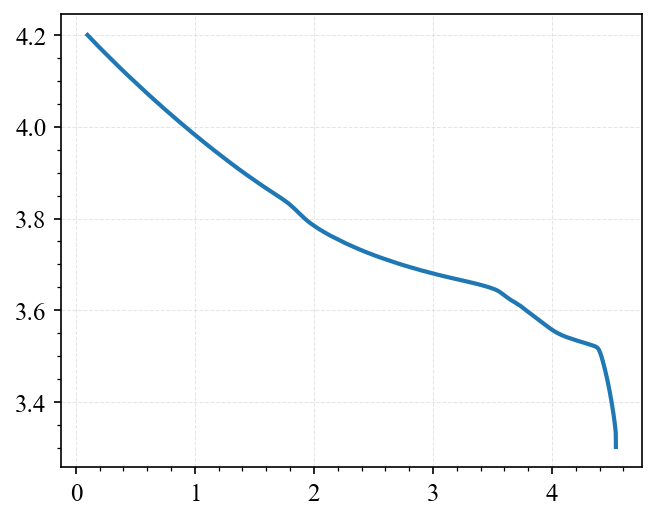

In [6]:
idx_I = np.where((np.diff(I_c1)<-0.02) & (I_c1[:-1]>0) & (I_c1[:-1]<2))[0] 
# idx_I = idx_I[idx_I>50]
t = t_c1[:idx_I[0]]
V = V_c1[:idx_I[0]]
I = I_c1[:idx_I[0]]
E = E_c1[:idx_I[0]]-E_c1[0]
Qmax = max(cyc_data["Q [Ah]"])

Q = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
Q = Qmax - Q
Qdata = Q
Vdata = V
fig, ax = plt.subplots(1,1,figsize=(5,4))
# ax.plot(t_c1,I_c1)
# ax.plot(t_c1[idx_I],I_c1[idx_I],'ro')
ax.plot(Q,V)

In [7]:
def OCP1(X,Q):
    ocp = Up(X[3]-Q/X[2])-Un(X[1]+Q/X[0])
    return ocp

def fitfunc1(x,Qdata,Vdata,R,Crate):
  model = np.concatenate([
         [OCP1(x,Q)+R*Crate*5]
        for Q in Qdata
    ]
  )
  Vd = Vdata
  Vs = model
  error = Vd-Vs
  out = np.linalg.norm(error)/np.sqrt(len(Vd))
  return out

def fitfunc3(x,Qdata,Vdata,Qmax,R,Crate):
  model = np.concatenate([
         [OCP1(x,Q)+R*Crate*5]
        for Q in Qdata
    ]
  )
  Q1 = 0.1*Qmax
  Q2 = 0.9*Qmax
  wvec = np.ones(len(Qdata))
  for i,Q in enumerate(Qdata):
     if Q<Q1 or Q>Q2:
        wvec[i]=0
  Vd = np.multiply(Vdata,wvec)
  Vs = np.multiply(model,wvec)
  error = Vd-Vs
  out = np.linalg.norm(error)/np.sqrt(len(Vd))
  return out

In [8]:
def load_cycling_data_ch(cyc_data_raw1,cyc_no):
    cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == cyc_no ]
    cyc_data = cyc_data_raw.reset_index(drop=True)
    t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
    t_c1 = t_c1.values
    I_c1 = cyc_data['Current [mA]']/1000
    I_c1 = I_c1.values
    V_c1 = cyc_data['Voltage [V]']
    V_c1 = V_c1.values
    E_c1 = cyc_data["Expansion [mu m]"]
    E_c1 = E_c1.values
    Q_c1 = cyc_data["Q [Ah]"]
    Q_c1 = Q_c1.values
    Q_c1 = Q_c1 - Q_c1[0]
    idx_I = np.where((np.diff(I_c1)<-0.02) & (I_c1[:-1]>0) & (I_c1[:-1]<2))[0] 
    t = t_c1[:idx_I[0]]
    V = V_c1[:idx_I[0]]
    I = I_c1[:idx_I[0]]
    E = E_c1[:idx_I[0]]-E_c1[0]
    Q = Q_c1[:idx_I[0]]
    Qmax = max(cyc_data["Q [Ah]"]-cyc_data["Q [Ah]"].iloc[0])
    Qi = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
    Q1 = Q
    Q2 = Qmax - Q1
    return t,V,I,Q1,Q2,Qmax


In [9]:
lb = [1, 0, 1, 0]
ub = [7, 1, 7, 1]
bounds = Bounds(lb, ub)
x0 = [6,0.01,6,0.9]

In [10]:
cell = 1
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
# for cyc_no in tqdm(range(1,5)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2,Qmax = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 1/5
        result = minimize(fitfunc3, x0, args=(Q_d1,V_d,Qmax,R,Crate), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)

 35%|███▌      | 133/380 [01:59<03:00,  1.37it/s]

134
index 0 is out of bounds for axis 0 with size 0


100%|██████████| 380/380 [05:28<00:00,  1.16it/s]


In [11]:
df1 = pd.DataFrame({"N":Na,"Cn":Cna})
df11 = df1.copy()
Cn_134 = (df11.query("N == 133").Cn.iloc[0] + df11.query("N == 135").Cn.iloc[0])/2
df1 =pd.concat([df11,pd.DataFrame([[134,Cn_134]], columns=df11.columns)], ignore_index=True)
df1 = df1.sort_values("N").reset_index(drop=True)
df1["Type"] = "cyc"

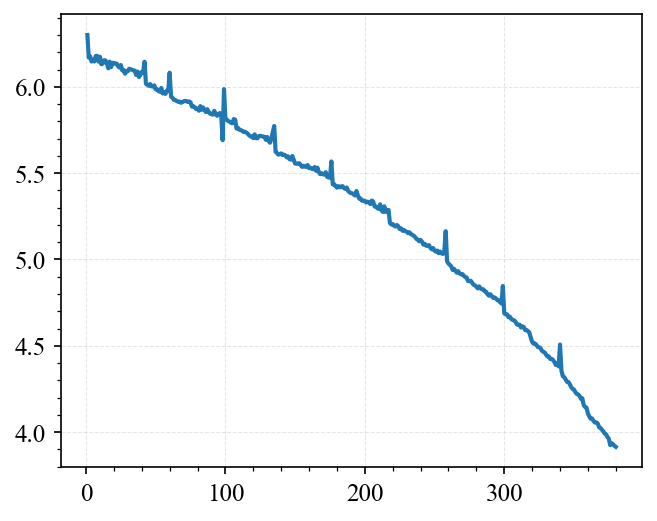

In [12]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df1["N"],df1["Cn"])

In [13]:
# df20 = pd.read_csv("C_5.csv")

In [14]:
# fig,ax = plt.subplots(1,1,figsize=(5,4))
# ax.plot(df1["N"],df1["Cn"])
# ax.plot(df20["N"],df20["Cn"])

In [16]:
Cna = []
Na = []
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(N_0):
    # try:
        cyc_data_raw1 = dfo_0[dfo_0["N"] == cyc_no]
        Q_d = cyc_data_raw1["Q"].values
        V_d = cyc_data_raw1["V"].values
        Q_d1 = Q_d[::5]
        V_d = V_d[::5]
        Qmax = max(Q_d)
        Q_d2 = Qmax - Q_d1
        if cyc_no >1:
            x0 = [np.average(Cna[-2:]),np.average(xa[-2:]),np.average(Cpa[-2:]),np.average(ya[-2:])]
        result = minimize(fitfunc3, x0, args=(Q_d1,V_d,Qmax,R,0), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])

100%|██████████| 11/11 [00:22<00:00,  2.08s/it]


In [17]:
df12 = pd.DataFrame({"N":Na,"Cn":Cna})
df12["Type"] = "rpt"
df_1 = pd.concat([df1,df12])
df_1 = df_1.sort_values("N").reset_index(drop=True)

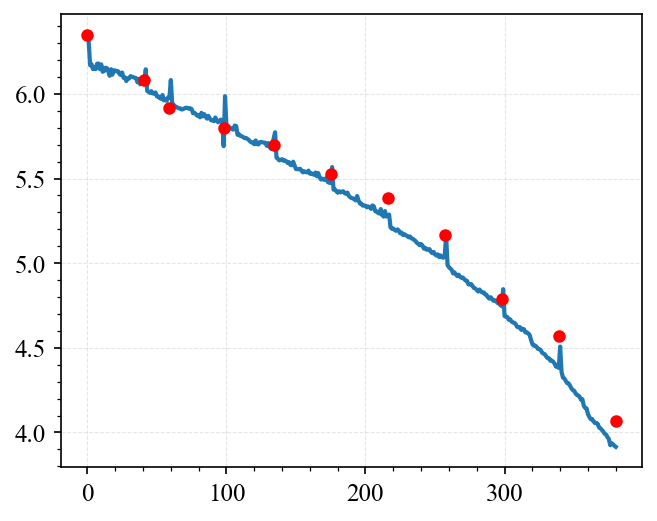

In [18]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df1["N"],df1["Cn"])
ax.plot(df12["N"],df12["Cn"],'ro')
# ax.plot(df12["N"],df_1["Cn"],'ro')


In [19]:
cell = 4
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
# for cyc_no in tqdm(range(1,5)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2,Qmax = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 1.5
        result = minimize(fitfunc3, x0, args=(Q_d1,V_d,Qmax,R,Crate), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)

100%|██████████| 328/328 [00:43<00:00,  7.52it/s]


In [20]:
df2 = pd.DataFrame({"N":Na,"Cn":Cna})

In [21]:
df2["Type"] = "cyc"

In [22]:
Cna = []
Na = []
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(N_0):
    # try:
        cyc_data_raw1 = dfo_0[dfo_0["N"] == cyc_no]
        Q_d = cyc_data_raw1["Q"].values
        V_d = cyc_data_raw1["V"].values
        Q_d1 = Q_d[::5]
        V_d = V_d[::5]
        Qmax = max(Q_d)
        Q_d2 = Qmax - Q_d1
        if cyc_no >1:
            x0 = [np.average(Cna[-2:]),np.average(xa[-2:]),np.average(Cpa[-2:]),np.average(ya[-2:])]
        result = minimize(fitfunc3, x0, args=(Q_d1,V_d,Qmax,R,0), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])

100%|██████████| 9/9 [00:16<00:00,  1.87s/it]


In [23]:
df21 = pd.DataFrame({"N":Na,"Cn":Cna})
df21["Type"] = "rpt"
df_2 = pd.concat([df2,df21])
df_2 = df_2.sort_values("N").reset_index(drop=True)

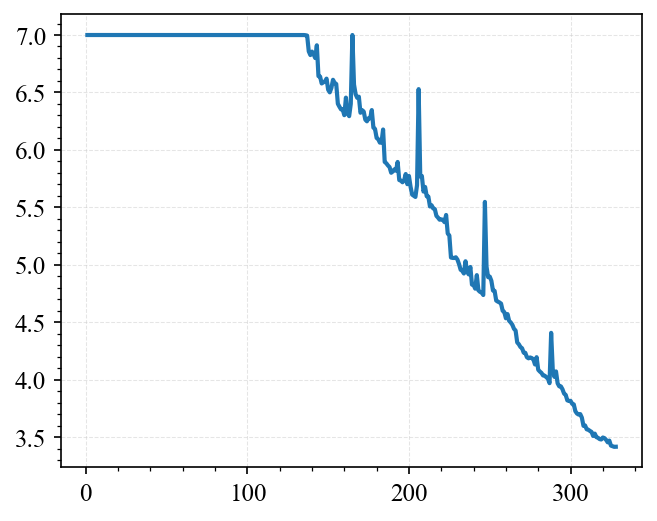

In [24]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df2["N"],df2["Cn"])

In [25]:
cell = 10
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
cyc_data_raw1['Cycle number'] = cyc_data_raw1['Cycle number'] + 1
xa, ya, Cna, Cpa = np.array([]), np.array([]), np.array([]), np.array([])
Na = np.array([])
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(range(1,max(cyc_data_raw1['Cycle number'])+1)):
# for cyc_no in tqdm(range(1,5)):
    try:
        if cyc_no >1:
            x0 = [np.average(Cna[-10:]),np.average(xa[-10:]),np.average(Cpa[-10:]),np.average(ya[-10:])]
        t_d,V_d,I_d,Q_d1,Q_d2,Qmax = load_cycling_data_ch(cyc_data_raw1,cyc_no)
        Q_d1 = Q_d1[::2]
        Q_d2 = Q_d2[::2]
        V_d = V_d[::2]
        R = dfe_0.iloc[(dfe_0['N']-cyc_no).abs().argsort()[:1]]["Rs_ave"].iloc[0]
        Crate = 1/5
        result = minimize(fitfunc3, x0, args=(Q_d1,V_d,Qmax,R,Crate), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])
    except Exception as error:
        print(cyc_no)
        print(error)

 81%|████████  | 357/440 [05:47<01:35,  1.15s/it]

358
index 0 is out of bounds for axis 0 with size 0


100%|██████████| 440/440 [06:55<00:00,  1.06it/s]


In [26]:
df3 = pd.DataFrame({"N":Na,"Cn":Cna})
df31 = df3.copy()
Cn_358 = (df31.query("N == 357").Cn.iloc[0] + df31.query("N == 359").Cn.iloc[0])/2
df3 =pd.concat([df31,pd.DataFrame([[359,Cn_134]], columns=df31.columns)], ignore_index=True)
df3 = df3.sort_values("N").reset_index(drop=True)
df3["Type"] = "cyc"

In [27]:
Cna = []
Na = []
x0 = [6,0.01,6,0.9]
for cyc_no in tqdm(N_0):
    # try:
        cyc_data_raw1 = dfo_0[dfo_0["N"] == cyc_no]
        Q_d = cyc_data_raw1["Q"].values
        V_d = cyc_data_raw1["V"].values
        Q_d1 = Q_d[::5]
        V_d = V_d[::5]
        Qmax = max(Q_d)
        Q_d2 = Qmax - Q_d1
        if cyc_no >1:
            x0 = [np.average(Cna[-2:]),np.average(xa[-2:]),np.average(Cpa[-2:]),np.average(ya[-2:])]
        result = minimize(fitfunc3, x0, args=(Q_d1,V_d,Qmax,R,0), bounds=bounds)
        res = result.x
        Na = np.append(Na,cyc_no)
        Cna = np.append(Cna,res[0])
        xa = np.append(xa,res[1])
        Cpa = np.append(Cpa,res[2])
        ya = np.append(ya,res[3])

100%|██████████| 12/12 [00:21<00:00,  1.79s/it]


In [28]:
df31 = pd.DataFrame({"N":Na,"Cn":Cna})
df31["Type"] = "rpt"
df_3 = pd.concat([df3,df31])
df_3 = df_3.sort_values("N").reset_index(drop=True)

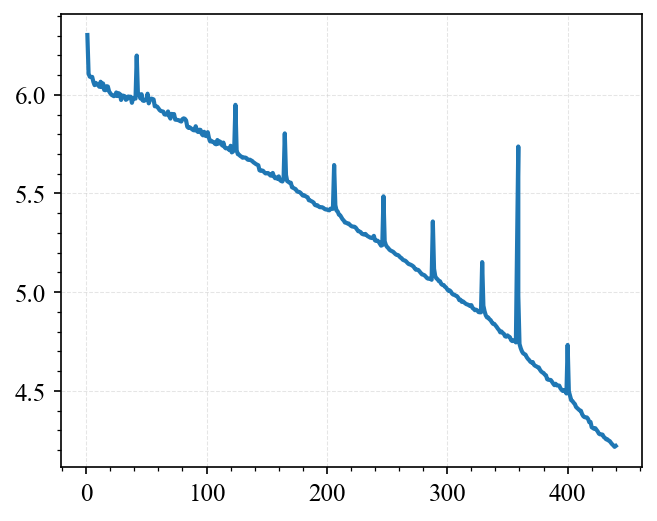

In [29]:
fig,ax = plt.subplots(1,1,figsize=(5,4))

ax.plot(df3["N"],df3["Cn"])

In [30]:
# df_1.to_csv("C_5_v2.csv")
# df_2.to_csv("C_1p5_v2.csv")
# df_3.to_csv("C_5_50_v2.csv")

In [31]:
df_1 = df_1.sort_values(["N","Type"],ascending=True).reset_index(drop=True)
df_1 = df_1.reset_index()
df_1["N"] = df_1["index"] + 1
df_1 = df_1.drop(columns=["index"])
df_2 = df_2.sort_values(["N","Type"],ascending=True).reset_index(drop=True)
df_2 = df_2.reset_index()
df_2["N"] = df_2["index"] + 1
df_2 = df_2.drop(columns=["index"])
df_3 = df_3.sort_values(["N","Type"],ascending=True).reset_index(drop=True)
df_3 = df_3.reset_index()
df_3["N"] = df_3["index"] + 1
df_3 = df_3.drop(columns=["index"])

In [32]:
df_11 = df_1.query("Type == 'rpt'")
df_12 = df_1.query("Type == 'cyc'")
df_21 = df_2.query("Type == 'rpt'")
df_22 = df_2.query("Type == 'cyc'")
df_31 = df_3.query("Type == 'rpt'")
df_32 = df_3.query("Type == 'cyc'")

In [33]:
N1 = df_1["N"].to_numpy()
crate = 1/5
DOD = 1
A = 6.0690 + 0.0288*DOD - 0.0143*crate + 0.0138*DOD*crate
B = -0.0808 - 0.0227*DOD*crate + 0.0190*DOD + 0.0171*crate
C = 2.4634e-6 - (1.0717e-5)*DOD + (1.7256e-8)*crate + (2.5483e-6)*DOD*crate
Cn1 = A + B*N1**0.4 + C*(N1**2)*np.tanh(N1)

N2 = df_2["N"].to_numpy()
crate = 1.5
DOD = 1
A = 6.3743 - 0.1553*crate
B = -0.0083 - 0.056*crate
C = 2.8773e-05 - (2.8319e-05)*crate
Cn2 = A + B*N2**0.4 + C*(N2**2)*np.tanh(N2)

N3 = df_3["N"].to_numpy()
crate = 1/5
DOD = 0.5
A = 6.0690 + 0.0288*DOD - 0.0143*crate + 0.0138*DOD*crate
B = -0.0808 - 0.0227*DOD*crate + 0.0190*DOD + 0.0171*crate
C = 2.4634e-6 - (1.0717e-5)*DOD + (1.7256e-8)*crate + (2.5483e-6)*DOD*crate
Cn3 = A + B*N3**0.4 + C*(N3**2)*np.tanh(N3)

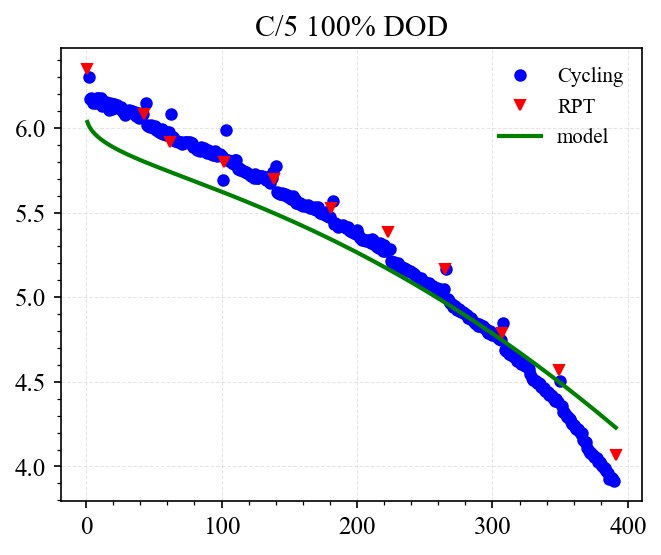

In [34]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df_12["N"],df_12["Cn"],color="blue",linestyle="none",marker="o")
ax.plot(df_11["N"],df_11["Cn"],color="red",linestyle="none",marker="v")
ax.plot(N1,Cn1,color="green")
ax.legend(["Cycling","RPT","model"])
ax.set_title("C/5 100% DOD")
fig.savefig("C_5.png")

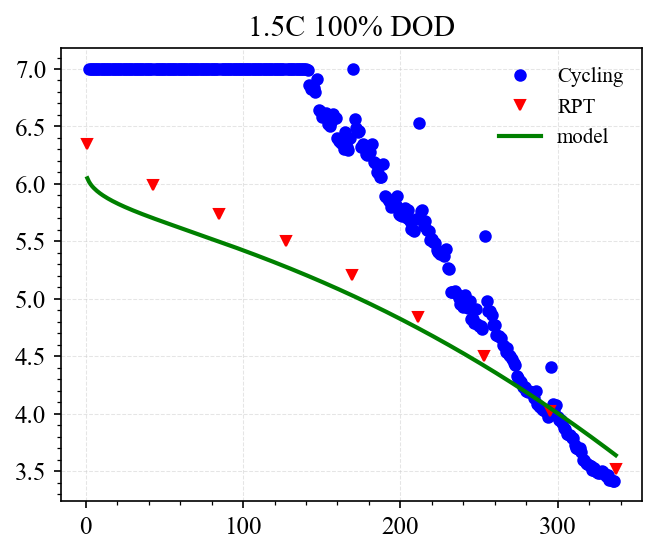

In [35]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df_22["N"],df_22["Cn"],color="blue",linestyle="none",marker="o")
ax.plot(df_21["N"],df_21["Cn"],color="red",linestyle="none",marker="v")
ax.plot(N2,Cn2,color="green")
ax.legend(["Cycling","RPT","model"])
ax.set_title("1.5C 100% DOD")
fig.savefig("C_1p5.png")

In [39]:
df31

,N,Cn,Type
0,0.0,6.351060,rpt
1,41.0,5.998318,rpt
2,82.0,5.902491,rpt
3,123.0,5.787601,rpt
4,164.0,5.689444,rpt
5,205.0,5.517473,rpt
6,246.0,5.402017,rpt
7,287.0,5.240007,rpt
8,328.0,5.106766,rpt
9,358.0,4.858329,rpt


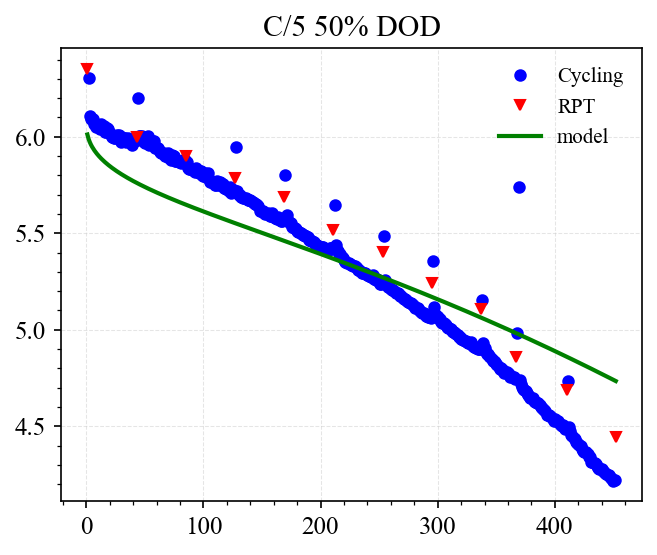

In [36]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(df_32["N"],df_32["Cn"],color="blue",linestyle="none",marker="o")
ax.plot(df_31["N"],df_31["Cn"],color="red",linestyle="none",marker="v")
ax.plot(N3,Cn3,color="green")
ax.legend(["Cycling","RPT","model"])
ax.set_title("C/5 50% DOD")
fig.savefig("C_5_50.png")

In [37]:
df_1["L"] = 1
df_2["L"] = 0
df_2.loc[df_2["Type"] == 'rpt',"L"] = 1
df_3["L"] = 0
df_3.loc[df_3["Type"] == 'rpt',"L"] = 1

In [38]:
df_1.to_csv("C_5_v2.csv")
df_2.to_csv("C_1p5_v2.csv")
df_3.to_csv("C_5_50_v2.csv")